In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import zipfile
import os

zip_path = "/content/unemployment.zip"

extract_path = "/content/unemployment"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [12]:
os.listdir("/content/unemployment")



['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']

In [13]:
import pandas as pd

csv_file = "/content/unemployment/Unemployment in India.csv"

df = pd.read_csv(csv_file)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [17]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [14]:
df.shape

(768, 7)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [16]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [20]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [21]:
# Data Cleaning

df.columns = df.columns.str.strip()

In [22]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [23]:
df.dropna(inplace=True)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.rename(columns={
    'Estimated Unemployment Rate (%)':'Unemployment Rate',
    'Estimated Employed':'Employed',
    'Estimated Labour Participation Rate (%)':'Labour Participation Rate'
}, inplace=True)


df.head()

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [26]:
df['Date'] = pd.to_datetime(df['Date'].str.strip())

df.head()

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [27]:
avg_unemployment = df['Unemployment Rate'].mean()

print(
    "Average Unemployment Rate:",
    round(avg_unemployment,2),
    "%"
)

Average Unemployment Rate: 11.79 %


In [28]:
print(
    "Maximum Unemployment Rate:",
    df['Unemployment Rate'].max(),
    "%"
)

Maximum Unemployment Rate: 76.74 %


In [29]:
print(
    "Minimum Unemployment Rate:",
    df['Unemployment Rate'].min(),
    "%"
)

Minimum Unemployment Rate: 0.0 %


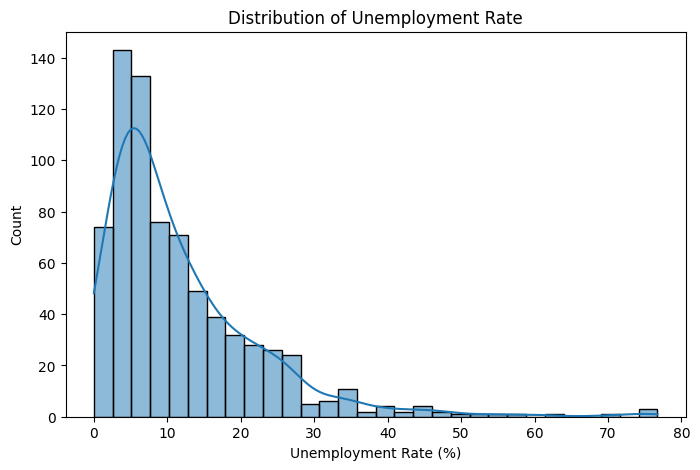

In [32]:
# Unemployment Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Unemployment Rate'],
    bins=30,
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.xlabel("Unemployment Rate (%)")

plt.show()

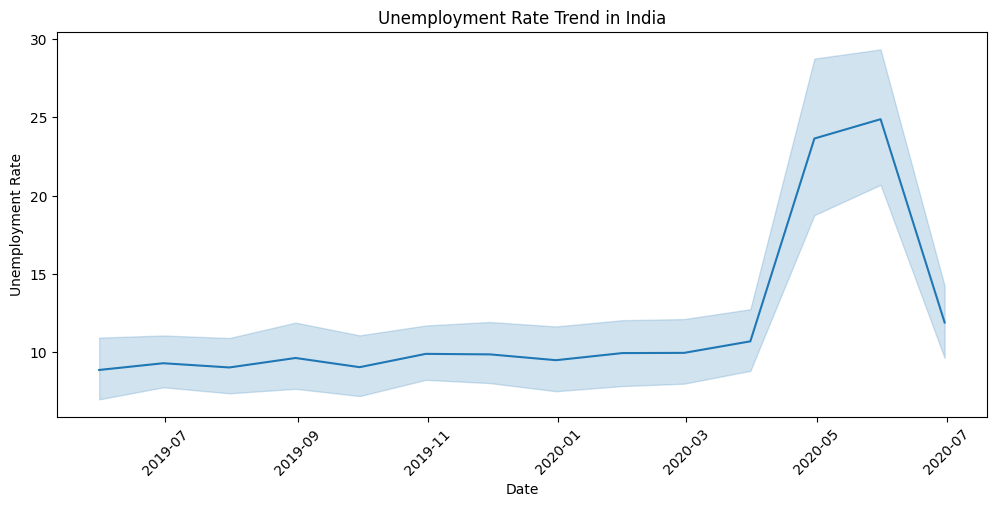

In [31]:
plt.figure(figsize=(12,5))


sns.lineplot(
    data=df,
    x='Date',
    y='Unemployment Rate'
)


plt.title(
    "Unemployment Rate Trend in India"
)


plt.xticks(rotation=45)

plt.show()

In [33]:
# Covid-19 Impact Analysis
df['Covid Period'] = np.where(
    df['Date'] < '2020-03-01',
    'Before Covid',
    'During Covid'
)

df.head()

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Area,Covid Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,Before Covid
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,Before Covid
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,Before Covid
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,Before Covid
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,Before Covid


In [34]:
covid_effect = df.groupby(
    'Covid Period'
)['Unemployment Rate'].mean()


covid_effect

,Unemployment Rate
Covid Period,
Before Covid,9.509534
During Covid,17.774363


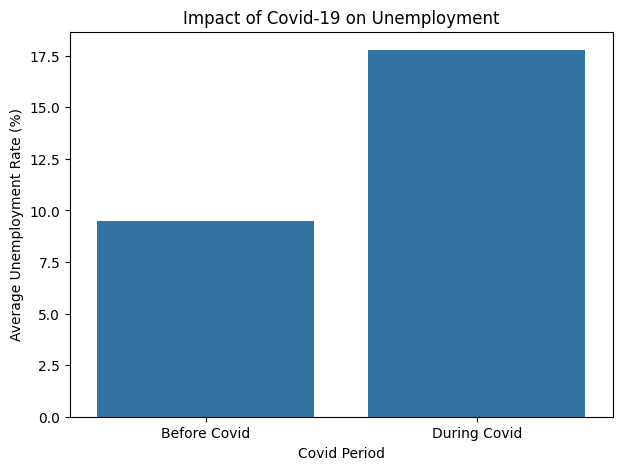

In [35]:
plt.figure(figsize=(7,5))


sns.barplot(
    x=covid_effect.index,
    y=covid_effect.values
)


plt.title(
    "Impact of Covid-19 on Unemployment"
)

plt.ylabel(
    "Average Unemployment Rate (%)"
)


plt.show()

In [36]:
state_analysis = df.groupby(
    'Region'
)['Unemployment Rate'].mean().sort_values(
    ascending=False
)


state_analysis.head(10)

,Unemployment Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


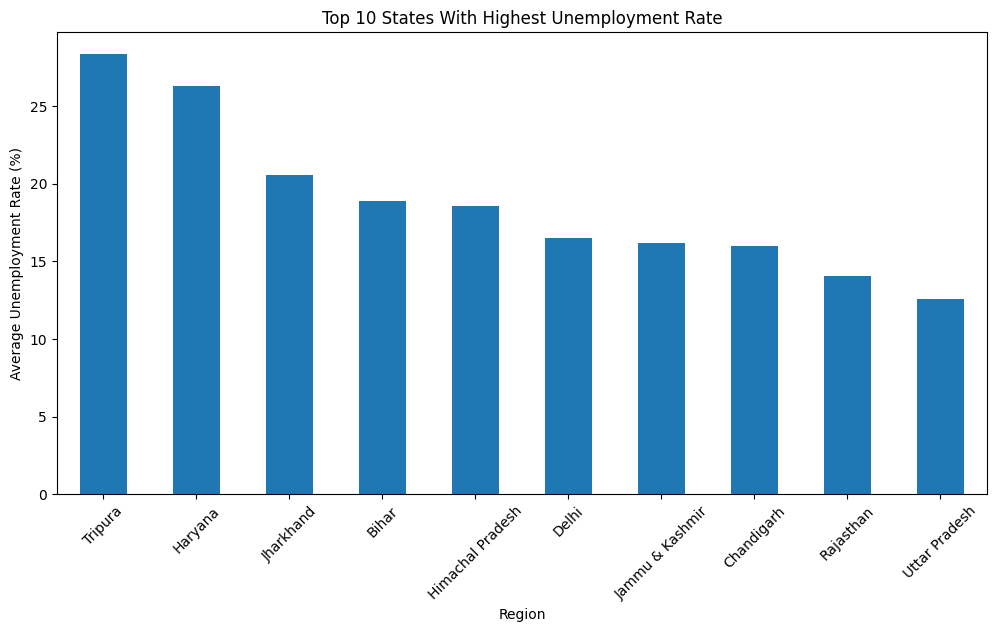

In [37]:
plt.figure(figsize=(12,6))


state_analysis.head(10).plot(
    kind='bar'
)


plt.title(
    "Top 10 States With Highest Unemployment Rate"
)


plt.ylabel(
    "Average Unemployment Rate (%)"
)


plt.xticks(rotation=45)

plt.show()

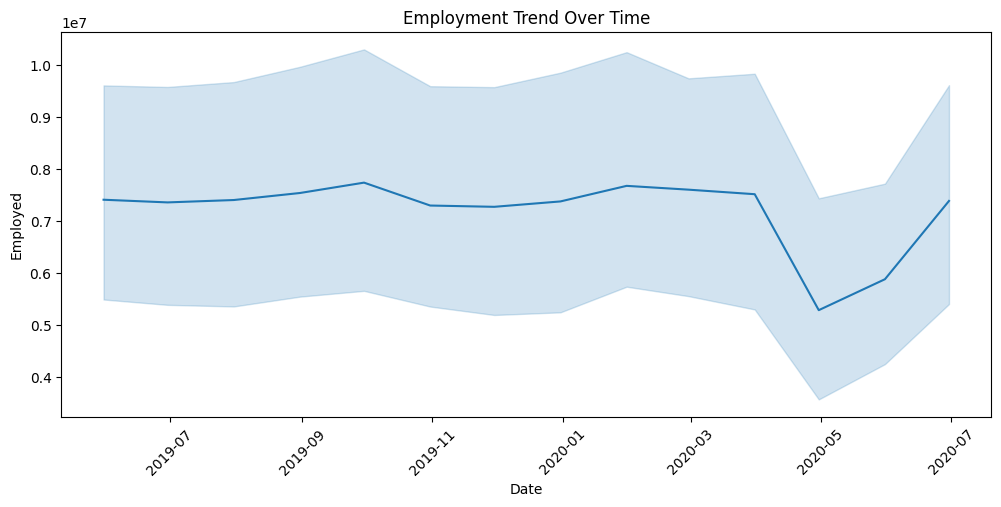

In [38]:
plt.figure(figsize=(12,5))


sns.lineplot(
    data=df,
    x='Date',
    y='Employed'
)


plt.title(
    "Employment Trend Over Time"
)


plt.xticks(rotation=45)

plt.show()

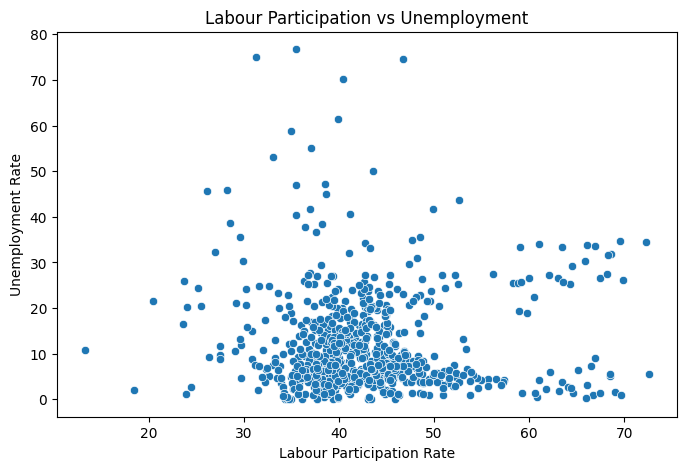

In [39]:
plt.figure(figsize=(8,5))


sns.scatterplot(
    data=df,
    x='Labour Participation Rate',
    y='Unemployment Rate'
)


plt.title(
    "Labour Participation vs Unemployment"
)


plt.show()

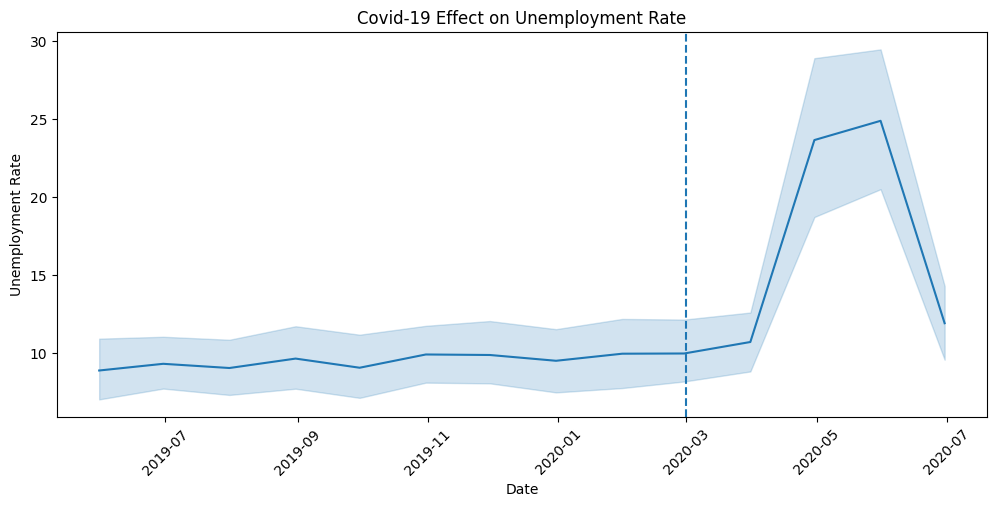

In [48]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x="Date",
    y="Unemployment Rate"
)

plt.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--"
)

plt.title(
    "Covid-19 Effect on Unemployment Rate"
)

plt.xticks(rotation=45)

plt.show()

In [49]:

# Area-wise analysis (Urban vs Rural)
area_analysis = df.groupby(
    "Area"
)["Unemployment Rate"].mean()

area_analysis

,Unemployment Rate
Area,
Rural,10.324791
Urban,13.166614


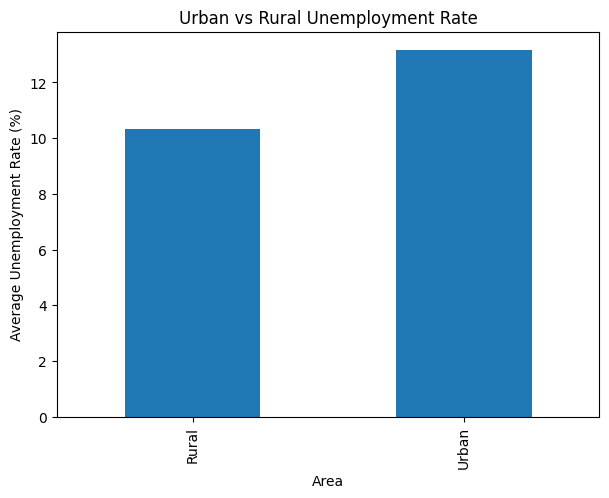

In [50]:
area_analysis.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title(
    "Urban vs Rural Unemployment Rate"
)

plt.ylabel(
    "Average Unemployment Rate (%)"
)

plt.show()

In [40]:
df['Month'] = df['Date'].dt.month

In [41]:
monthly_unemployment = df.groupby(
    'Month'
)['Unemployment Rate'].mean()


monthly_unemployment

,Unemployment Rate
Month,
1,9.950755
2,9.964717
3,10.700577
4,23.641569
5,16.646190
6,10.553462
7,9.033889
8,9.637925
9,9.051731


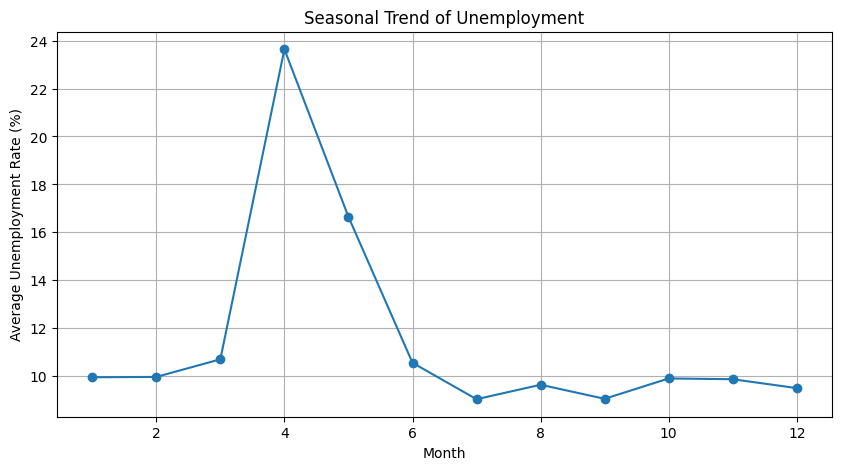

In [42]:
plt.figure(figsize=(10,5))


monthly_unemployment.plot(
    marker='o'
)


plt.title(
    "Seasonal Trend of Unemployment"
)


plt.xlabel("Month")

plt.ylabel(
    "Average Unemployment Rate (%)"
)


plt.grid()

plt.show()

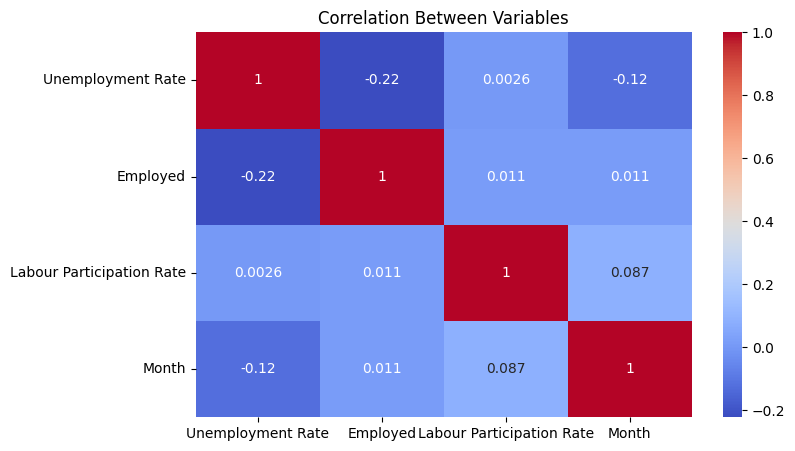

In [43]:
plt.figure(figsize=(8,5))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Correlation Between Variables"
)


plt.show()

In [44]:
print("Highest Unemployment States")

state_analysis.head(10)

Highest Unemployment States


,Unemployment Rate
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [45]:
print("Lowest Unemployment States")

state_analysis.tail(10)

Lowest Unemployment States


,Unemployment Rate
Region,
Maharashtra,7.557500
Andhra Pradesh,7.477143
Madhya Pradesh,7.406429
Sikkim,7.249412
Karnataka,6.676071
Gujarat,6.663929
Uttarakhand,6.582963
Assam,6.428077
Odisha,5.657857


In [46]:
print("""
PROJECT INSIGHTS:

1. Covid-19 caused a significant increase in unemployment rates.

2. Several states experienced higher unemployment compared to others.

3. Employment levels declined during the pandemic period.

4. Seasonal variations affect unemployment trends.

5. Labour participation rate has a relationship with unemployment.

6. Government policies focusing on job creation,
   skill development, and employment support can reduce unemployment.
""")


PROJECT INSIGHTS:

1. Covid-19 caused a significant increase in unemployment rates.

2. Several states experienced higher unemployment compared to others.

3. Employment levels declined during the pandemic period.

4. Seasonal variations affect unemployment trends.

5. Labour participation rate has a relationship with unemployment.

6. Government policies focusing on job creation,
   skill development, and employment support can reduce unemployment.



In [47]:
df.to_csv(
    "Clean_Unemployment_Data.csv",
    index=False
)